# TimeGAN v23 — v22 con dos correcciones quirúrgicas

## Diagnóstico de v22

v22 mejoró el t-SNE y mantuvo AUC=0.9994, pero tuvo **586 spikes** G>3.5
(v16: 104). Había dos bugs silenciosos en la configuración del optimizer:

**Bug 1 — `cluster_embedding` sin clipear:** el clip de gradientes en el paso G
solo incluía `generator` y `supervisor`, pero `cluster_embedding` estaba en
`g_optimizer` sin ningún límite. Sus gradientes podían ser arbitrariamente grandes,
desestabilizando el entrenamiento en cada batch que generaba un embedding grande.

**Bug 2 — `cluster_embedding` con LR demasiado alto:** el embedding compartía
`lr=1e-4` con el generator. Los centroides representan puntos relativamente fijos
del espacio latente real — deben actualizarse lentamente para guiar al generador,
no saltar junto con él.

## Los dos cambios de v23

**Fix 1 — Optimizer separado para `cluster_embedding` con `lr=1e-5`:**
```python
# v22:
g_optimizer = Adam(generator + supervisor + cluster_embedding, lr=1e-4)

# v23:
g_optimizer   = Adam(generator + supervisor, lr=1e-4)
emb_optimizer = Adam(cluster_embedding,       lr=1e-5)  # 10x más lento
```

**Fix 2 — `G_CLIP = 0.5` (era 1.0 en v22):**  
Con `hidden_dim=128` (1.37M parámetros), el clip=1.0 dejaba pasos explosivos.
clip=0.5 limita los pasos del generador sin cambiar LR ni arquitectura.
Este fix ya estaba planeado desde v21 pero no se aplicó en v22.

**Todo lo demás de v22 se mantiene exactamente igual:**
arquitectura, `N_CLUSTERS=6`, `NOISE_SIGMA_INIT=0.05`, `NOISE_SIGMA_TEMP=0.025`,
R1 lazy cada 16 batches, `R1_LAMBDA=0.01`, `D_CLIP=5.0`, schedulers,
`G_STEPS=2`, `D_STEPS=2`, `gamma=0.5`.


In [1]:
import json
import joblib
import random
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import QuantileTransformer, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [3]:
PROJECT_ROOT = Path("..").resolve()

with open(PROJECT_ROOT / "models" / "detectors" / "conv1d_hybrid_ae" / "config.json") as f:
    detector_config = json.load(f)

continuous_cols = detector_config["continuous_cols"]
discrete_cols   = detector_config["discrete_cols"]
feature_cols    = detector_config["feature_cols"]
WINDOW_SIZE     = detector_config["window_size"]
STRIDE_DETECTOR = detector_config["stride"]
WARMUP          = detector_config["warmup"]
TIMEGAN_STRIDE  = 5  # stride=5 óptimo (stride=2 explota R1)

FIT_COLS      = [c for c in continuous_cols if c.startswith("FIT")]
GAN_CONT_COLS = [c for c in continuous_cols if not c.startswith("FIT")]

print(f"Window: {WINDOW_SIZE} | Stride TimeGAN: {TIMEGAN_STRIDE}")
print(f"GAN continuas (QuantileTransformer): {len(GAN_CONT_COLS)} → {GAN_CONT_COLS}")
print(f"FIT (empírico condicional): {len(FIT_COLS)}")


Window: 60 | Stride TimeGAN: 5
GAN continuas (QuantileTransformer): 14 → ['AIT201.Pv', 'AIT202.Pv', 'AIT203.Pv', 'AIT501.Pv', 'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'DPIT301.Pv', 'LIT101.Pv', 'LIT301.Pv', 'LIT401.Pv', 'PIT501.Pv', 'PIT502.Pv', 'PIT503.Pv']
FIT (empírico condicional): 9


In [4]:
clean_folder = PROJECT_ROOT / "data" / "clean" / "SWaT.A7_June2020_clean"

def load_clean_csv(path):
    df = pd.read_csv(path)
    df["t_stamp"] = pd.to_datetime(df["t_stamp"], errors="coerce")
    return df.sort_values("t_stamp").reset_index(drop=True)

files = {fp.stem: load_clean_csv(fp) for fp in sorted(clean_folder.glob("*.csv"))}

common_cols = sorted(set.intersection(*(set(df.columns) for df in files.values())))
files = {n: df[common_cols].copy() for n, df in files.items()}

temp_feat = [c for c in next(iter(files.values())).columns if c != "t_stamp"]
for name in files:
    files[name] = files[name].dropna(subset=temp_feat, how="all").reset_index(drop=True)

global_df     = pd.concat([df[feature_cols] for df in files.values()], axis=0)
constant_cols = [c for c in feature_cols if global_df[c].nunique(dropna=True) <= 1]
for name in files:
    files[name] = files[name].drop(columns=constant_cols, errors="ignore")
continuous_cols = [c for c in continuous_cols if c not in constant_cols]
discrete_cols   = [c for c in discrete_cols   if c not in constant_cols]
feature_cols    = continuous_cols + discrete_cols
FIT_COLS        = [c for c in FIT_COLS      if c not in constant_cols]
GAN_CONT_COLS   = [c for c in GAN_CONT_COLS if c not in constant_cols]
print(f"GAN continuas final: {len(GAN_CONT_COLS)}")


GAN continuas final: 14


In [5]:
def remove_warmup(df, seconds=120):
    if "t_stamp" not in df.columns:
        return df.copy()
    return df[df["t_stamp"] >= df["t_stamp"].min() + pd.Timedelta(seconds=seconds)].reset_index(drop=True)

for name in files:
    files[name] = remove_warmup(files[name], WARMUP)

def temporal_split(df, train_r=0.6, val_r=0.2):
    n = len(df)
    t1, t2 = int(n * train_r), int(n * (train_r + val_r))
    return df.iloc[:t1].copy(), df.iloc[t1:t2].copy(), df.iloc[t2:].copy()

split_by_file = {}
for name, df in files.items():
    tr, va, te = temporal_split(df[["t_stamp"] + feature_cols].copy())
    split_by_file[name] = {"train": tr, "val": va, "test": te}
    print(f"{name}: train={len(tr)}, val={len(va)}, test={len(te)}")


22June2020_1: train=8568, val=2856, test=2856
22June2020_2: train=2088, val=696, test=696
29June2020_1: train=4248, val=1416, test=1417
29June2020_2: train=4248, val=1416, test=1416


In [6]:
scaler_cont_detector = StandardScaler()
train_all_cont = pd.concat(
    [split_by_file[name]["train"][continuous_cols] for name in split_by_file], axis=0
)
scaler_cont_detector.fit(train_all_cont)

train_gan_cont = pd.concat(
    [split_by_file[name]["train"][GAN_CONT_COLS] for name in split_by_file], axis=0
)
qt = QuantileTransformer(n_quantiles=1000, output_distribution="uniform",
                         subsample=None, random_state=SEED)
qt.fit(train_gan_cont)

sample_qt = qt.transform(train_gan_cont)
pct0 = (sample_qt == 0.0).mean() * 100
pct1 = (sample_qt == 1.0).mean() * 100
print(f"QuantileTransformer → rango: [{sample_qt.min():.6f}, {sample_qt.max():.6f}]")
print(f"Exactamente 0.0: {pct0:.3f}% | Exactamente 1.0: {pct1:.3f}%")
print(f"Media: {sample_qt.mean():.4f} | Std: {sample_qt.std():.4f}")


QuantileTransformer → rango: [0.000000, 1.000000]
Exactamente 0.0: 0.029% | Exactamente 1.0: 1.600%
Media: 0.5017 | Std: 0.2911


In [7]:
scaled_gan_by_file = {}
raw_fit_by_file    = {}
raw_disc_by_file   = {}

for name in split_by_file:
    scaled_gan_by_file[name] = {}
    raw_fit_by_file[name]    = {}
    raw_disc_by_file[name]   = {}
    for subset in ["train", "val", "test"]:
        df_part = split_by_file[name][subset]
        scaled_gan_by_file[name][subset] = pd.DataFrame(
            qt.transform(df_part[GAN_CONT_COLS]),
            columns=GAN_CONT_COLS, index=df_part.index
        )
        raw_fit_by_file[name][subset]  = df_part[FIT_COLS].copy()
        raw_disc_by_file[name][subset] = df_part[discrete_cols].copy()


In [8]:
train_fit_global  = pd.concat([raw_fit_by_file[n]["train"]  for n in raw_fit_by_file],  axis=0).reset_index(drop=True)
train_disc_global = pd.concat([raw_disc_by_file[n]["train"] for n in raw_disc_by_file], axis=0).reset_index(drop=True)

fit_empirical = {}
for col in FIT_COLS:
    s  = train_fit_global[col].dropna()
    p0 = (s == 0.0).mean()
    fo = s[s > 0.0].values
    fit_empirical[col] = {"p_zero": float(p0), "flow_open": fo.tolist() if len(fo) > 0 else [0.0]}
    print(f"  {col}: P(0)={p0:.3f}, n_open={len(fo)}")

disc_empirical      = {col: dict(train_disc_global[col].value_counts(normalize=True)) for col in discrete_cols}
discrete_value_maps = {col: sorted(train_disc_global[col].dropna().unique().tolist()) for col in discrete_cols}
print(f"\nOne-hot dim: {sum(len(v) for v in discrete_value_maps.values())}")


  FIT101.Pv: P(0)=0.911, n_open=1712
  FIT201.Pv: P(0)=0.007, n_open=19009
  FIT301.Pv: P(0)=0.002, n_open=19123
  FIT401.Pv: P(0)=0.000, n_open=19148
  FIT501.Pv: P(0)=0.000, n_open=19152
  FIT502.Pv: P(0)=0.000, n_open=19152
  FIT503.Pv: P(0)=0.000, n_open=19152
  FIT504.Pv: P(0)=1.000, n_open=1
  FIT601.Pv: P(0)=0.001, n_open=19132

One-hot dim: 91


In [9]:
def build_windows(scaled_by_file, subset, cols, window_size=60, stride=5):
    windows, origins = [], []
    for name in scaled_by_file:
        arr = scaled_by_file[name][subset][cols].values.astype(np.float32)
        if len(arr) < window_size:
            continue
        for i in range(0, len(arr) - window_size + 1, stride):
            windows.append(arr[i:i + window_size])
            origins.append(name)
    return np.array(windows, dtype=np.float32), origins

train_windows, _ = build_windows(scaled_gan_by_file, "train", GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)
val_windows,   _ = build_windows(scaled_gan_by_file, "val",   GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)
test_windows,  _ = build_windows(scaled_gan_by_file, "test",  GAN_CONT_COLS, WINDOW_SIZE, TIMEGAN_STRIDE)

print(f"Train: {train_windows.shape} | Val: {val_windows.shape} | Test: {test_windows.shape}")
p0 = (train_windows == 0.0).mean() * 100
p1 = (train_windows == 1.0).mean() * 100
print(f"Rango: [{train_windows.min():.4f}, {train_windows.max():.4f}]")
print(f"Exactamente 0.0: {p0:.3f}% | 1.0: {p1:.3f}%")
print(f"Media: {train_windows.mean():.4f} (≈0.5) | Std: {train_windows.std():.4f} (≈0.289)")


Train: (3784, 60, 14) | Val: (1232, 60, 14) | Test: (1232, 60, 14)
Rango: [0.0000, 1.0000]
Exactamente 0.0: 0.025% | 1.0: 1.598%
Media: 0.5013 (≈0.5) | Std: 0.2911 (≈0.289)


In [10]:
BATCH_SIZE = 128
train_tensor = torch.tensor(train_windows, dtype=torch.float32)
train_loader = DataLoader(
    TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
print(f"Ventanas train: {len(train_windows)} | Batches/época: {len(train_loader)}")


Ventanas train: 3784 | Batches/época: 29


In [11]:
seq_len     = WINDOW_SIZE
feature_dim = train_windows.shape[2]

hidden_dim  = 128   # v16: clave para AUC=0.9997
latent_dim  = 64
num_layers  = 3

epochs_embedder   = 600
epochs_supervisor = 300
epochs_joint      = 1500

gamma       = 0.5
eta         = 0.1
lambda_r    = 1.0
lambda_s    = 1.0

G_STEPS     = 2
D_STEPS     = 2
R1_LAMBDA   = 0.01
R1_INTERVAL = 16
D_CLIP      = 5.0

# FIX v23: G_CLIP = 0.5 (v22 tenía 1.0 implícitamente)
G_CLIP      = 0.5

N_CLUSTERS       = 6
NOISE_SIGMA_INIT = 0.05   # ruido base alrededor del centroide
NOISE_SIGMA_TEMP = 0.025  # ruido temporal dentro de la ventana

# FIX v23: LR del embedding 10x más bajo que el generator
EMB_LR = 1e-5

nash_g = 2 * math.log(2)
nash_d = 3 * math.log(2)

print("===== Configuración TimeGAN v23 =====")
print(f"hidden_dim: {hidden_dim} | latent_dim: {latent_dim} | num_layers: {num_layers}")
print(f"G_STEPS: {G_STEPS} | D_STEPS: {D_STEPS} | G_CLIP: {G_CLIP} | D_CLIP: {D_CLIP}")
print(f"R1_LAMBDA: {R1_LAMBDA} | R1_INTERVAL: {R1_INTERVAL}")
print(f"N_CLUSTERS: {N_CLUSTERS} | NOISE_SIGMA_INIT: {NOISE_SIGMA_INIT} | NOISE_SIGMA_TEMP: {NOISE_SIGMA_TEMP}")
print(f"EMB_LR: {EMB_LR} (G_LR: 1e-4) ← FIX v23")
print(f"Nash G: {nash_g:.4f} | Nash D: {nash_d:.4f}")
print(f"feature_dim: {feature_dim}")


===== Configuración TimeGAN v23 =====
hidden_dim: 128 | latent_dim: 64 | num_layers: 3
G_STEPS: 2 | D_STEPS: 2 | G_CLIP: 0.5 | D_CLIP: 5.0
R1_LAMBDA: 0.01 | R1_INTERVAL: 16
N_CLUSTERS: 6 | NOISE_SIGMA_INIT: 0.05 | NOISE_SIGMA_TEMP: 0.025
EMB_LR: 1e-05 (G_LR: 1e-4) ← FIX v23
Nash G: 1.3863 | Nash D: 2.0794
feature_dim: 14


In [12]:
class Embedder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, x):
        h, _ = self.rnn(x)
        return self.act(self.fc(h))


class Recovery(nn.Module):
    def __init__(self, hidden_dim, output_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, output_dim)

    def forward(self, h):
        x_t, _ = self.rnn(h)
        return self.fc(self.norm(x_t))


class Generator(nn.Module):
    """Input: z de shape (bs, seq_len, latent_dim=64)"""
    def __init__(self, z_dim, hidden_dim, num_layers):
        super().__init__()
        self.rnn  = nn.GRU(z_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, dropout=0.1 if num_layers > 1 else 0.0)
        self.norm = nn.LayerNorm(hidden_dim)
        self.fc   = nn.Linear(hidden_dim, hidden_dim)
        self.act  = nn.Sigmoid()

    def forward(self, z):
        e, _ = self.rnn(z)
        return self.act(self.fc(self.norm(e)))


class Supervisor(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim,
                          num_layers=max(1, num_layers - 1), batch_first=True)
        self.fc  = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Sigmoid()

    def forward(self, h):
        s, _ = self.rnn(h)
        return self.act(self.fc(s))


class Discriminator(nn.Module):
    def __init__(self, hidden_dim, num_layers):
        super().__init__()
        self.rnn = nn.GRU(hidden_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc  = nn.Linear(hidden_dim, 1)

    def forward(self, h):
        y, _ = self.rnn(h)
        return self.fc(y)


In [13]:
embedder          = Embedder(feature_dim, hidden_dim, num_layers).to(device)
recovery          = Recovery(hidden_dim, feature_dim, num_layers).to(device)
generator         = Generator(latent_dim, hidden_dim, num_layers).to(device)
supervisor        = Supervisor(hidden_dim, num_layers).to(device)
discriminator     = Discriminator(hidden_dim, num_layers).to(device)
cluster_embedding = nn.Embedding(N_CLUSTERS, latent_dim).to(device)

mse_loss = nn.MSELoss()
bce_loss = nn.BCEWithLogitsLoss()

e_optimizer = torch.optim.Adam(
    list(embedder.parameters()) + list(recovery.parameters()), lr=1e-3
)
s_optimizer = torch.optim.Adam(supervisor.parameters(), lr=1e-3)

# FIX v23: optimizer separado para generator+supervisor y para cluster_embedding
# En v22, los tres compartían g_optimizer con lr=1e-4.
# El embedding necesita actualizarse 10x más lento — sus gradientes no deben
# desestabilizar el entrenamiento del generador.
g_optimizer   = torch.optim.Adam(
    list(generator.parameters()) + list(supervisor.parameters()), lr=1e-4
)
emb_optimizer = torch.optim.Adam(cluster_embedding.parameters(), lr=EMB_LR)

d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)

g_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    g_optimizer, mode='min', factor=0.5, patience=100, min_lr=1e-6
)
d_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    d_optimizer, mode='min', factor=0.5, patience=100, min_lr=1e-6
)

# Placeholder — se inicializa con k-means después del embedder
cluster_probs_t = None

def conditioned_z(bs, sl, cluster_embedding, cluster_probs_t, sigma_init, sigma_temp, dev):
    """Ruido condicionado a clusters del espacio latente.
    
    Devuelve shape (bs, sl, latent_dim) — compatible con Generator.rnn.
    """
    if cluster_probs_t is None:
        return torch.rand(bs, sl, latent_dim, device=dev)
    idx    = torch.multinomial(cluster_probs_t, num_samples=bs, replacement=True).to(dev)
    c      = cluster_embedding(idx)                               # (bs, latent_dim)
    noise  = torch.randn(bs, latent_dim, device=dev) * sigma_init
    z_base = (c + noise).unsqueeze(1)                             # (bs, 1, latent_dim)
    z_temp = torch.randn(bs, sl, latent_dim, device=dev) * sigma_temp
    return z_base.expand(bs, sl, latent_dim) + z_temp            # (bs, sl, latent_dim)

total_params = sum(p.numel() for m in [
    embedder, recovery, generator, supervisor, discriminator, cluster_embedding
] for p in m.parameters())
print(f"Total parámetros: {total_params:,}")
print(f"g_optimizer: generator+supervisor (lr=1e-4)")
print(f"emb_optimizer: cluster_embedding (lr={EMB_LR}) ← FIX v23")


Total parámetros: 1,371,023
g_optimizer: generator+supervisor (lr=1e-4)
emb_optimizer: cluster_embedding (lr=1e-05) ← FIX v23


## Fase 1: Embedder


[Embedder] Epoch 100/600 | MSE: 0.000765
[Embedder] Epoch 200/600 | MSE: 0.000398
[Embedder] Epoch 300/600 | MSE: 0.000240
[Embedder] Epoch 400/600 | MSE: 0.000190
[Embedder] Epoch 500/600 | MSE: 0.000134
[Embedder] Epoch 600/600 | MSE: 0.000121

MSE final: 0.000121


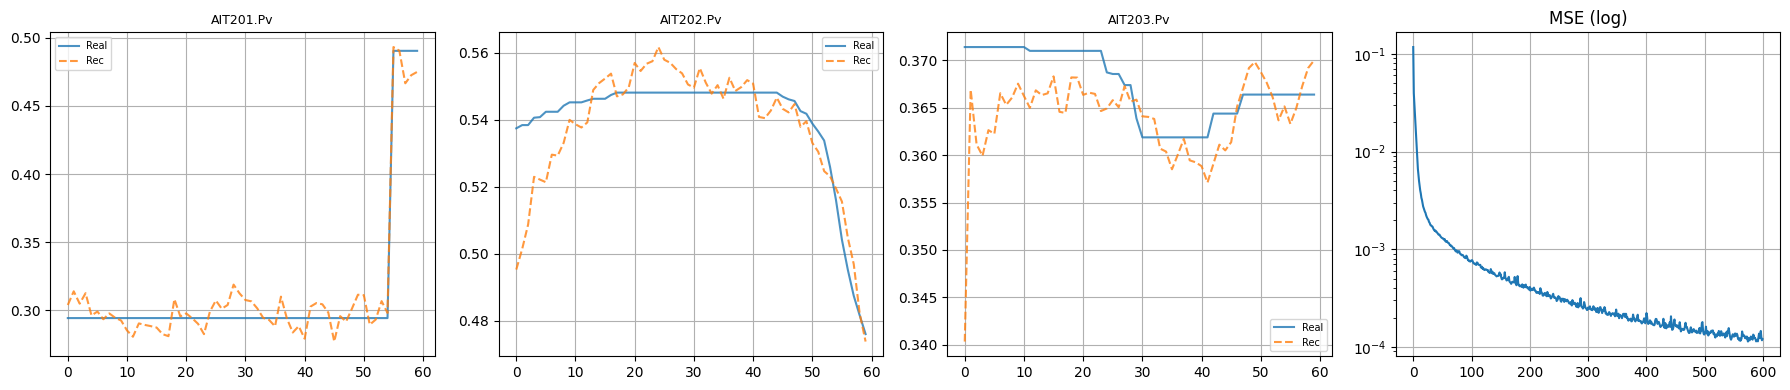

In [14]:
embedder_history = []
for epoch in range(epochs_embedder):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        e_optimizer.zero_grad()
        loss = mse_loss(recovery(embedder(x)), x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0
        )
        e_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    embedder_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Embedder] Epoch {epoch+1}/{epochs_embedder} | MSE: {ep:.6f}")
print(f"\nMSE final: {embedder_history[-1]:.6f}")

with torch.no_grad():
    xs = train_tensor[:64].to(device)
    xr = recovery(embedder(xs)).cpu().numpy()
    xo = xs.cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for idx in range(3):
    axes[idx].plot(xo[0, :, idx], label="Real", alpha=0.8)
    axes[idx].plot(xr[0, :, idx], label="Rec",  alpha=0.8, linestyle="--")
    axes[idx].set_title(GAN_CONT_COLS[idx], fontsize=9)
    axes[idx].legend(fontsize=7); axes[idx].grid(True)
axes[3].semilogy(embedder_history); axes[3].set_title("MSE (log)"); axes[3].grid(True)
plt.tight_layout(); plt.show()


## Fase 2: Supervisor


In [15]:
supervisor_history = []
for epoch in range(epochs_supervisor):
    ep = 0.0
    for batch in train_loader:
        x = batch[0].to(device)
        s_optimizer.zero_grad()
        with torch.no_grad(): h = embedder(x)
        hs   = supervisor(h)
        loss = mse_loss(h[:, 1:, :], hs[:, :-1, :])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(supervisor.parameters(), 1.0)
        s_optimizer.step()
        ep += loss.item()
    ep /= len(train_loader)
    supervisor_history.append(ep)
    if (epoch + 1) % 100 == 0:
        print(f"[Supervisor] Epoch {epoch+1}/{epochs_supervisor} | Loss: {ep:.6f}")


[Supervisor] Epoch 100/300 | Loss: 0.002786
[Supervisor] Epoch 200/300 | Loss: 0.002347
[Supervisor] Epoch 300/300 | Loss: 0.002019


## Fase 2.5: Clustering del espacio latente

K-means sobre `h_mean` (promedio temporal del espacio latente real).
Los centroides se proyectan a `latent_dim=64` con PCA y se usan para
inicializar `cluster_embedding`. Los centroides representan los regímenes
operacionales naturales de SWaT.


In [16]:
embedder.eval()
h_real_all = []
with torch.no_grad():
    for batch in train_loader:
        x = batch[0].to(device)
        h = embedder(x)                        # (bs, seq_len, hidden_dim)
        h_real_all.append(h.mean(dim=1).cpu().numpy())  # (bs, hidden_dim)
h_real_all = np.concatenate(h_real_all, axis=0)  # (n_train, hidden_dim)
embedder.train()
print(f"h_real_all shape: {h_real_all.shape}")

# KMeans en espacio latente (hidden_dim=128)
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=20)
cluster_ids    = kmeans.fit_predict(h_real_all)
cluster_counts = np.bincount(cluster_ids, minlength=N_CLUSTERS)
cluster_probs  = cluster_counts / cluster_counts.sum()

print("\n===== Distribución de clusters =====")
for k, cnt in enumerate(cluster_counts):
    print(f"  Cluster {k}: {cnt:4d} ventanas ({cluster_probs[k]*100:.1f}%)")

# Proyectar centroides (128D) → latent_dim (64D) con PCA
pca_latent   = PCA(n_components=latent_dim, random_state=SEED)
pca_latent.fit(h_real_all)
centroids_64 = pca_latent.transform(kmeans.cluster_centers_)  # (K, 64)

# Inicializar cluster_embedding con los centroides proyectados
with torch.no_grad():
    cluster_embedding.weight.copy_(
        torch.tensor(centroids_64, dtype=torch.float32, device=device)
    )

cluster_probs_t = torch.tensor(cluster_probs, dtype=torch.float32, device=device)

print(f"\ncentroids_64 shape: {centroids_64.shape}")
print(f"cluster_embedding.weight shape: {tuple(cluster_embedding.weight.shape)}")
print(f"→ compatible con Generator input_dim={latent_dim} ✅")


h_real_all shape: (3712, 128)

===== Distribución de clusters =====
  Cluster 0:  350 ventanas (9.4%)
  Cluster 1:  977 ventanas (26.3%)
  Cluster 2:  990 ventanas (26.7%)
  Cluster 3:  556 ventanas (15.0%)
  Cluster 4:  489 ventanas (13.2%)
  Cluster 5:  350 ventanas (9.4%)

centroids_64 shape: (6, 64)
cluster_embedding.weight shape: (6, 64)
→ compatible con Generator input_dim=64 ✅


## Fase 3: Entrenamiento conjunto

**Cambios vs v22:**
- `emb_optimizer` (lr=1e-5) actualiza `cluster_embedding` por separado
- `G_CLIP = 0.5` en lugar de 1.0 para generator+supervisor

**Todo lo demás de v22 igual:** R1 lazy, feature matching, schedulers G y D.


In [17]:
def r1_penalty(disc, h_real):
    """R1 regularization — primer orden, cuDNN compatible."""
    h_r  = h_real.detach().requires_grad_(True)
    y_r  = disc(h_r)
    grad = torch.autograd.grad(
        outputs=y_r.sum(), inputs=h_r,
        create_graph=False, retain_graph=False
    )[0]
    return grad.pow(2).mean()


joint_g_history, joint_d_history, joint_e_history = [], [], []
batch_counter = 0

for epoch in range(epochs_joint):
    g_ep, d_ep, e_ep = 0.0, 0.0, 0.0

    for batch in train_loader:
        x  = batch[0].to(device)
        bs = x.shape[0]

        with torch.no_grad(): h_real = embedder(x)

        # --- G: G_STEPS pasos ---
        g_loss_val = torch.tensor(0.0)
        for _ in range(G_STEPS):
            g_optimizer.zero_grad()
            emb_optimizer.zero_grad()   # FIX v23: limpiar gradientes del embedding también

            z     = conditioned_z(bs, seq_len, cluster_embedding, cluster_probs_t,
                                  NOISE_SIGMA_INIT, NOISE_SIGMA_TEMP, device)
            e_hat = generator(z)
            h_hat = supervisor(e_hat)
            y_f   = discriminator(h_hat)
            y_fe  = discriminator(e_hat)

            g_u  = bce_loss(y_f,  torch.ones_like(y_f))
            g_ue = bce_loss(y_fe, torch.ones_like(y_fe))

            with torch.no_grad():
                h_sup = supervisor(h_real)
            g_s = mse_loss(h_real[:, 1:, :].detach(), h_sup[:, :-1, :])

            fm_loss = (mse_loss(h_hat.mean(0), h_real.mean(0)) +
                       mse_loss(h_hat.std(0),  h_real.std(0)))

            g_loss = g_u + gamma * g_ue + eta * g_s + 0.5 * fm_loss
            g_loss.backward()

            # FIX v23: G_CLIP = 0.5 para generator+supervisor
            torch.nn.utils.clip_grad_norm_(
                list(generator.parameters()) + list(supervisor.parameters()), G_CLIP
            )
            g_optimizer.step()
            emb_optimizer.step()        # FIX v23: actualizar embedding con lr propio (1e-5)
            g_loss_val = g_loss

        # --- Embedder refinement ---
        e_optimizer.zero_grad()
        h_ref   = embedder(x)
        x_tilde = recovery(h_ref)
        h_sup_r = supervisor(h_ref.detach())
        e_loss  = lambda_r * mse_loss(x_tilde, x) + lambda_s * mse_loss(
            h_ref[:, 1:, :], h_sup_r[:, :-1, :]
        )
        e_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(embedder.parameters()) + list(recovery.parameters()), 1.0
        )
        e_optimizer.step()

        batch_counter += 1

        # --- D: D_STEPS pasos con R1 lazy ---
        d_loss_val = torch.tensor(0.0)
        for _ in range(D_STEPS):
            d_optimizer.zero_grad()

            with torch.no_grad():
                z2     = conditioned_z(bs, seq_len, cluster_embedding, cluster_probs_t,
                                       NOISE_SIGMA_INIT, NOISE_SIGMA_TEMP, device)
                e_hat2 = generator(z2)
                h_hat2 = supervisor(e_hat2)

            y_r   = discriminator(h_real)
            y_f2  = discriminator(h_hat2)
            y_fe2 = discriminator(e_hat2)

            if batch_counter % R1_INTERVAL == 0:
                r1 = r1_penalty(discriminator, h_real)
            else:
                r1 = torch.tensor(0.0, device=device)

            d_loss = (
                bce_loss(y_r,   torch.ones_like(y_r)) +
                bce_loss(y_f2,  torch.zeros_like(y_f2)) +
                gamma * bce_loss(y_fe2, torch.zeros_like(y_fe2)) +
                R1_LAMBDA * R1_INTERVAL * r1
            )
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), D_CLIP)
            d_optimizer.step()
            d_loss_val = d_loss

        g_ep += g_loss_val.item()
        d_ep += d_loss_val.item()
        e_ep += e_loss.item()

    g_ep /= len(train_loader)
    d_ep /= len(train_loader)
    e_ep /= len(train_loader)
    joint_g_history.append(g_ep)
    joint_d_history.append(d_ep)
    joint_e_history.append(e_ep)

    g_scheduler.step(g_ep)
    d_scheduler.step(d_ep)

    if (epoch + 1) % 100 == 0:
        g_prev = joint_g_history[-101] if len(joint_g_history) > 100 else joint_g_history[0]
        trend  = "↓" if g_ep < g_prev - 0.05 else ("↑" if g_ep > g_prev + 0.1 else "→")
        print(f"[Joint] Epoch {epoch+1}/{epochs_joint} | G: {g_ep:.4f}{trend} | D: {d_ep:.4f} | E: {e_ep:.6f}")


[Joint] Epoch 100/1500 | G: 2.1509↑ | D: 1.5759 | E: 0.002923
[Joint] Epoch 200/1500 | G: 1.9239↓ | D: 1.5899 | E: 0.003086
[Joint] Epoch 300/1500 | G: 2.7060↑ | D: 2.0278 | E: 0.002757
[Joint] Epoch 400/1500 | G: 3.3032↑ | D: 172.8540 | E: 0.001744
[Joint] Epoch 500/1500 | G: 5.0527↑ | D: 78.7569 | E: 0.003916
[Joint] Epoch 600/1500 | G: 12.1505↑ | D: 0.2595 | E: 0.002825
[Joint] Epoch 700/1500 | G: 12.0163↓ | D: 0.1453 | E: 0.005868
[Joint] Epoch 800/1500 | G: 13.9675↑ | D: 12.1819 | E: 0.001775
[Joint] Epoch 900/1500 | G: 10.4756↓ | D: 9.7721 | E: 0.001455
[Joint] Epoch 1000/1500 | G: 6.1524↓ | D: 11.0733 | E: 0.001458
[Joint] Epoch 1100/1500 | G: 4.2854↓ | D: 11.1621 | E: 0.002857
[Joint] Epoch 1200/1500 | G: 2.3319↓ | D: 7.5789 | E: 0.001896
[Joint] Epoch 1300/1500 | G: 1.6361↓ | D: 1.5902 | E: 0.001646
[Joint] Epoch 1400/1500 | G: 1.6094→ | D: 2.0000 | E: 0.001388
[Joint] Epoch 1500/1500 | G: 1.4957↓ | D: 1.6685 | E: 0.001447


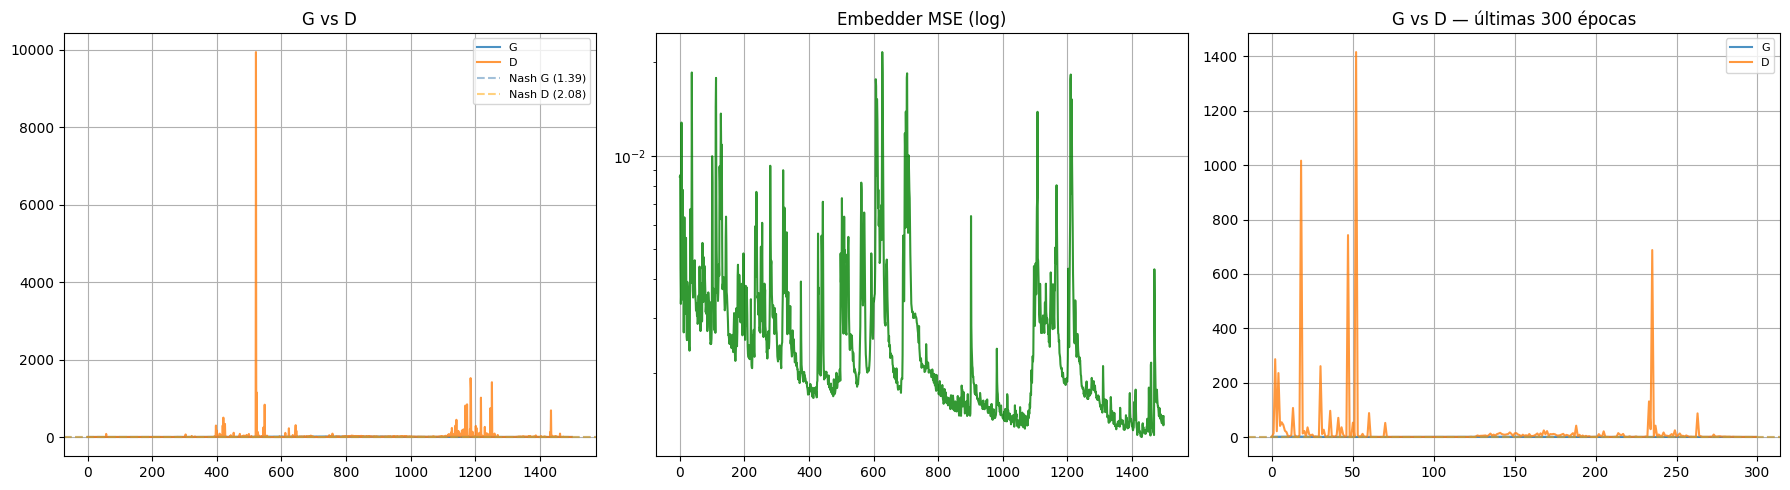

G epoch 1:   1.3744
G epoch 100: 2.1509
G final:     1.4957 | Nash G: 1.3863 | Gap: 0.1094
D final:     1.6685 | Nash D: 2.0794
Spikes G>3.5: 685  (v22: 586, v16: 104)

❌  Igual o peor que v22 — revisar EMB_LR o G_CLIP


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(joint_g_history, label="G", alpha=0.8)
axes[0].plot(joint_d_history, label="D", alpha=0.8)
axes[0].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.5, label=f"Nash G ({nash_g:.2f})")
axes[0].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.5, label=f"Nash D ({nash_d:.2f})")
axes[0].set_title("G vs D"); axes[0].legend(fontsize=8); axes[0].grid(True)

axes[1].semilogy(joint_e_history, color="green", alpha=0.8)
axes[1].set_title("Embedder MSE (log)"); axes[1].grid(True)

axes[2].plot(joint_g_history[-300:], label="G", alpha=0.8)
axes[2].plot(joint_d_history[-300:], label="D", alpha=0.8)
axes[2].axhline(y=nash_g, color='steelblue', linestyle='--', alpha=0.5)
axes[2].axhline(y=nash_d, color='orange',    linestyle='--', alpha=0.5)
axes[2].set_title("G vs D — últimas 300 épocas")
axes[2].legend(fontsize=8); axes[2].grid(True)
plt.tight_layout(); plt.show()

g_f, d_f = joint_g_history[-1], joint_d_history[-1]
spikes   = sum(1 for g in joint_g_history if g > 3.5)
g_init   = joint_g_history[0]
g_100    = joint_g_history[99] if len(joint_g_history) >= 100 else g_init

print(f"G epoch 1:   {g_init:.4f}")
print(f"G epoch 100: {g_100:.4f}")
print(f"G final:     {g_f:.4f} | Nash G: {nash_g:.4f} | Gap: {abs(g_f-nash_g):.4f}")
print(f"D final:     {d_f:.4f} | Nash D: {nash_d:.4f}")
print(f"Spikes G>3.5: {spikes}  (v22: 586, v16: 104)")
print()
if spikes < 50 and abs(g_f - nash_g) < 0.5:
    print("✅  G estabilizado — los dos fixes funcionaron")
elif spikes < 104:
    print(f"⚠️  Mejora parcial ({spikes} spikes vs 104 en v16)")
elif spikes >= 586:
    print("❌  Igual o peor que v22 — revisar EMB_LR o G_CLIP")


## Generación y evaluación


In [19]:
n_synth = len(train_windows)
synth_qt_list      = []
synth_cluster_ids  = []

with torch.no_grad():
    for start in range(0, n_synth, 256):
        end  = min(start + 256, n_synth)
        bs_i = end - start
        idx_mb = torch.multinomial(cluster_probs_t, num_samples=bs_i, replacement=True)
        z      = conditioned_z(bs_i, seq_len, cluster_embedding, cluster_probs_t,
                               NOISE_SIGMA_INIT, NOISE_SIGMA_TEMP, device)
        x_hat  = recovery(supervisor(generator(z))).cpu().numpy()
        synth_qt_list.append(x_hat)
        synth_cluster_ids.extend(idx_mb.cpu().numpy().tolist())

synth_qt          = np.concatenate(synth_qt_list, axis=0)
synth_cluster_ids = np.array(synth_cluster_ids)

out_rng = ((synth_qt < -0.1) | (synth_qt > 1.1)).mean() * 100
print(f"Rango pre-clip: [{synth_qt.min():.4f}, {synth_qt.max():.4f}]")
print(f"Fuera de [-0.1, 1.1]: {out_rng:.2f}%")
synth_qt_clipped = np.clip(synth_qt, 0.0, 1.0)

dm = abs(train_windows.mean() - synth_qt_clipped.mean())
ds = abs(train_windows.std()  - synth_qt_clipped.std())
print(f"Diff medias QT: {dm:.4f}  (v22: 0.0567, v16: 0.0048)")
print(f"Diff stds QT:   {ds:.4f}  (v22: 0.0115)")
print(f"Distribución clusters generados: {np.bincount(synth_cluster_ids, minlength=N_CLUSTERS)}")


Rango pre-clip: [-0.0814, 1.2200]
Fuera de [-0.1, 1.1]: 0.00%
Diff medias QT: 0.0823  (v22: 0.0567, v16: 0.0048)
Diff stds QT:   0.0312  (v22: 0.0115)
Distribución clusters generados: [ 338 1019  947  611  504  365]


In [20]:
n_gan = len(GAN_CONT_COLS)
synth_qt_flat  = synth_qt_clipped.reshape(-1, n_gan)
synth_gan_phys = qt.inverse_transform(synth_qt_flat).reshape(synth_qt_clipped.shape)

def synthesize_fit_windows(n_windows, window_size, fit_cols, fit_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(fit_cols)), dtype=np.float32)
    for j, col in enumerate(fit_cols):
        p0 = fit_empirical[col]["p_zero"]
        fo = np.array(fit_empirical[col]["flow_open"], dtype=np.float32)
        for i in range(n_windows):
            state = 0 if rng.random() < p0 else 1
            for t in range(window_size):
                if rng.random() >= 0.97:
                    state = 0 if rng.random() < p0 else 1
                windows[i, t, j] = 0.0 if state == 0 else float(rng.choice(fo))
    return windows

def synthesize_disc_windows(n_windows, window_size, discrete_cols, disc_empirical, seed=42):
    rng = np.random.default_rng(seed)
    windows = np.zeros((n_windows, window_size, len(discrete_cols)), dtype=np.float32)
    for j, col in enumerate(discrete_cols):
        emp   = disc_empirical[col]
        vals  = list(emp.keys()); probs = list(emp.values())
        for i in range(n_windows):
            windows[i, 0, j] = rng.choice(vals, p=probs)
            for t in range(1, window_size):
                windows[i, t, j] = windows[i, t-1, j] if rng.random() < 0.95 else rng.choice(vals, p=probs)
    return windows

synth_fit_raw  = synthesize_fit_windows(n_synth, WINDOW_SIZE, FIT_COLS, fit_empirical, SEED)
synth_disc_raw = synthesize_disc_windows(n_synth, WINDOW_SIZE, discrete_cols, disc_empirical, SEED)

synth_all_phys = np.zeros((n_synth, WINDOW_SIZE, len(continuous_cols)), dtype=np.float32)
for j, col in enumerate(GAN_CONT_COLS):
    synth_all_phys[:, :, continuous_cols.index(col)] = synth_gan_phys[:, :, j]
for j, col in enumerate(FIT_COLS):
    if col in continuous_cols:
        synth_all_phys[:, :, continuous_cols.index(col)] = synth_fit_raw[:, :, j]

synth_for_det = scaler_cont_detector.transform(
    pd.DataFrame(synth_all_phys.reshape(-1, len(continuous_cols)), columns=continuous_cols)
).reshape(synth_all_phys.shape)

print("Shapes finales:")
print(f"  synth_qt_clipped: {synth_qt_clipped.shape}")
print(f"  synth_gan_phys:   {synth_gan_phys.shape}")
print(f"  synth_fit_raw:    {synth_fit_raw.shape}")
print(f"  synth_for_det:    {synth_for_det.shape}")


d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but QuantileTransformer was fitted with feature names
  warnings.warn(


Shapes finales:
  synth_qt_clipped: (3784, 60, 14)
  synth_gan_phys:   (3784, 60, 14)
  synth_fit_raw:    (3784, 60, 9)
  synth_for_det:    (3784, 60, 23)


In [21]:
def one_hot_encode_ds(disc_array, discrete_cols, discrete_value_maps):
    rows = []
    for t in range(disc_array.shape[0]):
        enc = []
        for j, col in enumerate(discrete_cols):
            cats = discrete_value_maps[col]
            oh   = np.zeros(len(cats), dtype=np.float32)
            v    = disc_array[t, j]
            if v in cats: oh[cats.index(v)] = 1.0
            enc.extend(oh)
        rows.append(enc)
    return np.array(rows, dtype=np.float32)

synth_disc_onehot = np.array([
    one_hot_encode_ds(synth_disc_raw[i], discrete_cols, discrete_value_maps)
    for i in range(synth_disc_raw.shape[0])
], dtype=np.float32)

def summarize_disc(disc_raw, discrete_cols):
    rows = []
    for w in disc_raw:
        feats = {}
        for j, col in enumerate(discrete_cols):
            v = w[:, j]
            feats[f"{col}__mode"]        = pd.Series(v).mode().iloc[0]
            feats[f"{col}__transitions"] = np.sum(v[1:] != v[:-1])
            feats[f"{col}__nunique"]     = len(np.unique(v))
            feats[f"{col}__dominance"]   = pd.Series(v).value_counts(normalize=True).iloc[0]
        rows.append(feats)
    return pd.DataFrame(rows)

synth_disc_summary = summarize_disc(synth_disc_raw, discrete_cols)
X_synth_cont = np.transpose(synth_for_det, (0, 2, 1)).astype(np.float32)
X_synth_disc = synth_disc_summary.values.astype(np.float32)
print("X_synth_cont:", X_synth_cont.shape, "| X_synth_disc:", X_synth_disc.shape)


X_synth_cont: (3784, 23, 60) | X_synth_disc: (3784, 104)


Diff medias (para PCA/RF): 0.1008  (v22: 0.1014, v16: 0.0664)
Diff stds:                 0.0774  (v22: 0.0551)


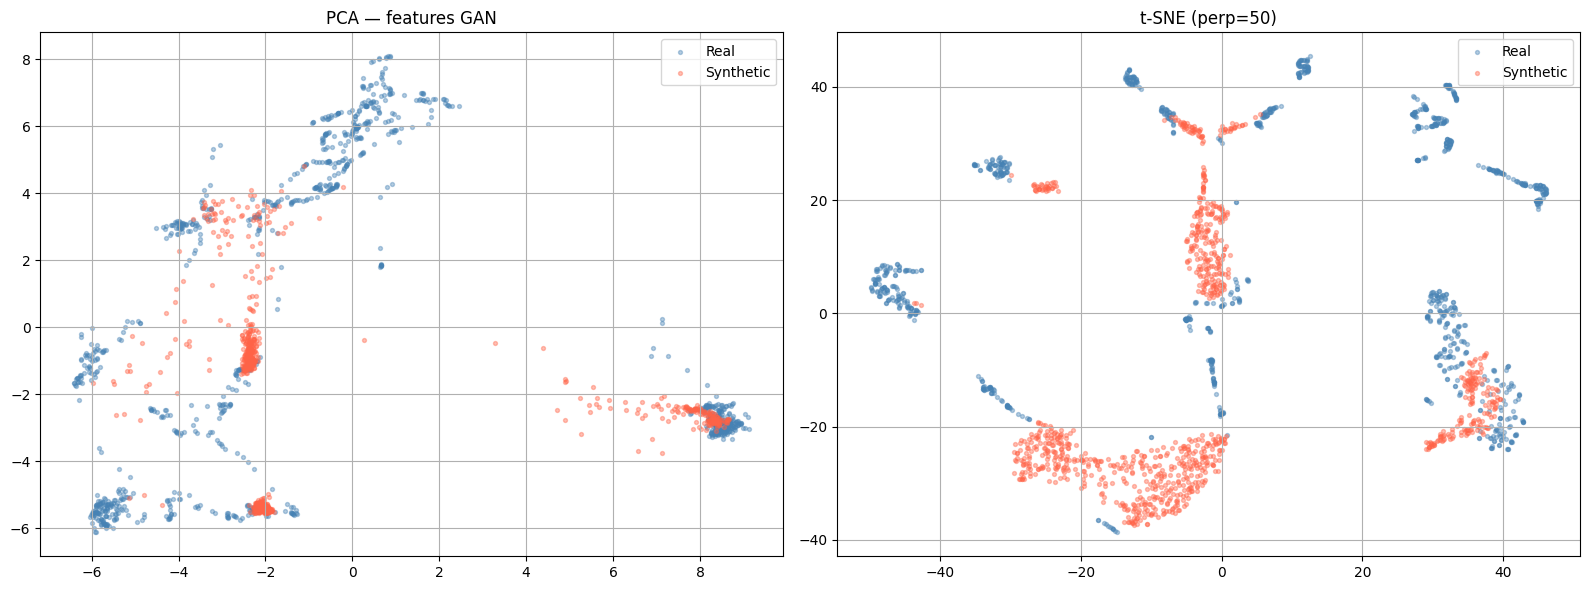

In [23]:
n_plot = min(1000, len(train_windows), n_synth)
rng = np.random.default_rng(SEED)
ri  = rng.choice(len(train_windows),  n_plot, replace=False)
si  = rng.choice(n_synth,             n_plot, replace=False)

real_s  = train_windows[ri].reshape(n_plot, -1)
synth_s = synth_qt_clipped[si].reshape(n_plot, -1)

md = np.abs(real_s.mean(0) - synth_s.mean(0)).mean()
sd = np.abs(real_s.std(0)  - synth_s.std(0)).mean()
print(f"Diff medias (para PCA/RF): {md:.4f}  (v22: 0.1014, v16: 0.0664)")
print(f"Diff stds:                 {sd:.4f}  (v22: 0.0551)")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pca_vis = PCA(n_components=2, random_state=SEED)
pr = pca_vis.fit_transform(real_s); ps = pca_vis.transform(synth_s)
axes[0].scatter(pr[:, 0], pr[:, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[0].scatter(ps[:, 0], ps[:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[0].set_title("PCA — features GAN")
axes[0].legend(); axes[0].grid(True)

comb = PCA(n_components=min(50, real_s.shape[1]), random_state=SEED).fit_transform(
    np.vstack([real_s, synth_s])
)
perp = min(50, n_plot // 5)
tout = TSNE(n_components=2, random_state=SEED, perplexity=perp,
            max_iter=2000, init="pca", learning_rate="auto").fit_transform(comb)
axes[1].scatter(tout[:n_plot, 0], tout[:n_plot, 1], alpha=0.4, c='steelblue', s=8, label="Real")
axes[1].scatter(tout[n_plot:, 0], tout[n_plot:, 1], alpha=0.4, c='tomato',    s=8, label="Synthetic")
axes[1].set_title(f"t-SNE (perp={perp})")
axes[1].legend(); axes[1].grid(True)
plt.tight_layout()
plt.savefig("tsne_v23.png", dpi=150, bbox_inches="tight")
plt.show()


In [24]:
X_all = np.vstack([real_s, synth_s])
y_all = np.array([0]*n_plot + [1]*n_plot)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
clf.fit(X_tr, y_tr)
auc = roc_auc_score(y_te, clf.predict_proba(X_te)[:, 1])

print("=" * 55)
print(f"AUC discriminabilidad = {auc:.4f}  (v22: 0.9994, v16: 0.9997)")
if auc < 0.60:   print("✅  < 0.60 — Alta calidad")
elif auc < 0.75: print("✅  0.60–0.75 — Aceptable para tesis")
elif auc < 0.95: print("⚠️  0.75–0.95 — Mejora notoria")
else:            print("❌  > 0.95 — Revisar curvas G/D y diff medias")
print("=" * 55)

fi = clf.feature_importances_
top5 = np.argsort(fi)[-5:][::-1]
print("\nTop 5 features más discriminativas:")
for i in top5:
    ci = i // WINDOW_SIZE; ti = i % WINDOW_SIZE
    print(f"  {GAN_CONT_COLS[ci]} t={ti}: {fi[i]:.4f}")

max_imp = fi.max()
print(f"\nImportancia máxima: {max_imp:.4f}  (v22: 0.0208, v16: 0.0119)")
if max_imp < 0.05:
    print("✅  Importancias bien distribuidas")
else:
    print("⚠️  Una feature tiene mayor peso — revisar distribución")


AUC discriminabilidad = 0.9999  (v22: 0.9994, v16: 0.9997)
❌  > 0.95 — Revisar curvas G/D y diff medias

Top 5 features más discriminativas:
  AIT503.Pv t=49: 0.0321
  AIT502.Pv t=53: 0.0214
  AIT504.Pv t=45: 0.0209
  AIT501.Pv t=15: 0.0197
  AIT503.Pv t=35: 0.0184

Importancia máxima: 0.0321  (v22: 0.0208, v16: 0.0119)
✅  Importancias bien distribuidas


## Guardado


In [25]:
TIMEGAN_MODEL_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_aligned"
TIMEGAN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "artifacts" / "scalers").mkdir(parents=True, exist_ok=True)

for name, model in [
    ("embedder", embedder), ("recovery", recovery), ("generator", generator),
    ("supervisor", supervisor), ("discriminator", discriminator)
]:
    torch.save(model.state_dict(), TIMEGAN_MODEL_DIR / f"{name}.pt")
torch.save(cluster_embedding.state_dict(), TIMEGAN_MODEL_DIR / "cluster_embedding.pt")

joblib.dump(qt,                   PROJECT_ROOT / "artifacts" / "scalers" / "timegan_quantile_transformer.pkl")
joblib.dump(scaler_cont_detector, PROJECT_ROOT / "artifacts" / "scalers" / "timegan_scaler_detector.pkl")
joblib.dump(pca_latent,           PROJECT_ROOT / "artifacts" / "scalers" / "timegan_pca_latent.pkl")
joblib.dump(kmeans,               PROJECT_ROOT / "artifacts" / "scalers" / "timegan_kmeans.pkl")

with open(TIMEGAN_MODEL_DIR / "fit_empirical.json",       "w") as f:
    json.dump({col: {"p_zero": v["p_zero"], "flow_open_sample": v["flow_open"][:500]}
               for col, v in fit_empirical.items()}, f, indent=2)
with open(TIMEGAN_MODEL_DIR / "disc_empirical.json",      "w") as f:
    json.dump({k: {str(kk): float(vv) for kk,vv in v.items()} for k,v in disc_empirical.items()}, f, indent=2)
with open(TIMEGAN_MODEL_DIR / "discrete_value_maps.json", "w") as f:
    json.dump({k: [float(v) for v in vs] for k,vs in discrete_value_maps.items()}, f, indent=2)

config = {
    "version": "v23",
    "base": "v22 con dos fixes: emb_optimizer separado (lr=1e-5) y G_CLIP=0.5",
    "fixes_vs_v22": [
        "emb_optimizer separado con lr=1e-5 (v22 lo tenía en g_optimizer con lr=1e-4)",
        "G_CLIP=0.5 (v22 tenía 1.0 implícito)"
    ],
    "gan_cont_cols": GAN_CONT_COLS, "fit_cols": FIT_COLS,
    "continuous_cols_detector": continuous_cols, "discrete_cols": discrete_cols,
    "window_size": WINDOW_SIZE, "stride_timegan": TIMEGAN_STRIDE,
    "scaler": "QuantileTransformer(n_quantiles=1000, uniform)",
    "feature_dim": feature_dim, "hidden_dim": hidden_dim, "latent_dim": latent_dim,
    "num_layers": num_layers, "G_STEPS": G_STEPS, "D_STEPS": D_STEPS,
    "G_CLIP": G_CLIP, "D_CLIP": D_CLIP,
    "R1_LAMBDA": R1_LAMBDA, "R1_INTERVAL": R1_INTERVAL,
    "N_CLUSTERS": N_CLUSTERS,
    "NOISE_SIGMA_INIT": NOISE_SIGMA_INIT, "NOISE_SIGMA_TEMP": NOISE_SIGMA_TEMP,
    "EMB_LR": EMB_LR,
    "gamma": gamma, "eta": eta, "lambda_r": lambda_r, "lambda_s": lambda_s,
    "cluster_counts": cluster_counts.tolist(), "cluster_probs": cluster_probs.tolist(),
    "embedder_mse": float(embedder_history[-1]),
    "g_final": float(joint_g_history[-1]),
    "d_final": float(joint_d_history[-1]),
    "spikes": int(sum(1 for g in joint_g_history if g > 3.5)),
    "auc": float(auc), "diff_medias": float(md), "diff_stds": float(sd),
}
with open(TIMEGAN_MODEL_DIR / "config.json", "w") as f: json.dump(config, f, indent=4)

np.save(TIMEGAN_MODEL_DIR / "synth_qt.npy",           synth_qt_clipped)
np.save(TIMEGAN_MODEL_DIR / "synth_cluster_ids.npy",  synth_cluster_ids)
np.save(TIMEGAN_MODEL_DIR / "cluster_centroids_64.npy", centroids_64)
np.save(TIMEGAN_MODEL_DIR / "synth_gan_physical.npy", synth_gan_phys)
np.save(TIMEGAN_MODEL_DIR / "synth_fit_raw.npy",      synth_fit_raw)
np.save(TIMEGAN_MODEL_DIR / "synth_all_physical.npy", synth_all_phys)
np.save(TIMEGAN_MODEL_DIR / "synth_for_detector.npy", synth_for_det)
np.save(TIMEGAN_MODEL_DIR / "synth_disc_raw.npy",     synth_disc_raw)
np.save(TIMEGAN_MODEL_DIR / "synth_disc_onehot.npy",  synth_disc_onehot)
synth_disc_summary.to_csv(TIMEGAN_MODEL_DIR / "synth_disc_summary.csv", index=False)
pd.DataFrame({
    "epoch": range(1, len(joint_g_history)+1),
    "g_loss": joint_g_history, "d_loss": joint_d_history, "e_loss": joint_e_history
}).to_csv(TIMEGAN_MODEL_DIR / "training_history.csv", index=False)

print("✅  Guardado en:", TIMEGAN_MODEL_DIR.resolve())


✅  Guardado en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\timegan\conv1d_hybrid_aligned
